In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
from glob import glob
from progress.bar import Bar
import pandas as pd

In [2]:
results = []
files = glob("experiment_results/*")
with Bar("Loading Results", max = len(files)) as bar:
    for file in files:
        with open(file) as f:
            results.append((file, json.loads(f.read().replace("inf", "Infinity"))))
            # try:
            #     results.append(json.load(f))
            # except:
            #     print(file)
            #     results.append(json.loads(f.read().replace("inf", "Infinity")))
        bar.next()

In [3]:
files

['experiment_results/den520d_47_79_156_216_sipp_0_784_0.outai13',
 'experiment_results/den520d_88_33_12_177_sipp_0_837_0.outai6',
 'experiment_results/den520d_220_51_214_123_sipp_0_188_0.outai14',
 'experiment_results/den520d_17_187_215_203_sipp_0_549_0.outai14',
 'experiment_results/den520d_200_68_76_45_sipp_0_340_0.outai12',
 'experiment_results/den520d_127_168_152_45_sipp_0_368_0.outai12',
 'experiment_results/den520d_245_10_203_192_sipp_0_563_0.outai9',
 'experiment_results/den520d_123_231_113_103_sipp_0_538_0.outai3',
 'experiment_results/den520d_18_182_120_39_sipp_0_735_0.outai4',
 'experiment_results/den520d_115_88_119_92_sipp_0_17_0.outai6',
 'experiment_results/den520d_40_161_153_108_sipp_0_406_0.outai8',
 'experiment_results/den520d_29_175_19_76_sipp_0_798_0.outai13',
 'experiment_results/den520d_84_197_236_39_sipp_0_600_0.outai4',
 'experiment_results/den520d_88_46_37_164_sipp_0_726_0.outai12',
 'experiment_results/den520d_97_190_70_135_sipp_0_166_0.outai5',
 'experiment_res

In [4]:
res = results[1]
res

('experiment_results/den520d_88_33_12_177_sipp_0_837_0.outai6',
 {'filename': 'maps/den520/den520d.map',
  'algorithm': 'sipp',
  'seed': 0,
  'scenario': {'start_x': 88, 'start_y': 33, 'goal_x': 12, 'goal_y': 177},
  'results': [{'arrival_time': 379.266,
    'metadata': {'generated': 331663,
     'decreased': 10064,
     'expanded': 315422,
     'learnexpanded': 0,
     'searchruntime_ms': 299.019,
     'learnruntime_ms': 0}}]})

In [3]:
columns = [
    "filename",
    "algorithm",
    "seed",
    "start_x", "start_y", "goal_x", "goal_y",
    "sum_generated",
    "sum_decreased",
    "sum_expanded",
    "n_tref",
    "runtime",
    "node",
    "arrival_time",
    "instance_id",
    "replicate"
]

def process_results(results):
    n_tref = 0
    sum_gen = 0
    sum_dec = 0
    sum_exp = 0
    runtime = 0.0
    for r in results:
        n_tref += 1
        sum_gen += r['metadata']['generated']
        sum_dec += r['metadata']['decreased']
        sum_exp += r['metadata']['expanded']
        runtime += r['metadata']['searchruntime_ms']
    return sum_gen, sum_dec, sum_exp, n_tref, runtime

In [4]:
def mkrow(res):
    node = res[0].split(".out")[-1]
    rep = res[0].split(".out")[0].split("_")[-1]
    instance = res[0].split(".out")[0].split("_")[-2]
    res = res[1]
    arrival_time = None
    try:
        arrival_time = res['results'][0]['arrival_time']
    except:
        arrival_time = res['results'][0]['reference_time']
    return [res['filename'], res['algorithm'], res['seed'], res['scenario']['start_x'], res['scenario']['start_y'], res['scenario']['goal_x'], res['scenario']['goal_y'],
 *process_results(res['results']), node, arrival_time, instance, rep]

In [5]:
x = []
for res in results:
    x.append(mkrow(res))
data = pd.DataFrame(data = x, columns = columns)

In [6]:
data.sum_generated.max()

np.int64(4109262757)

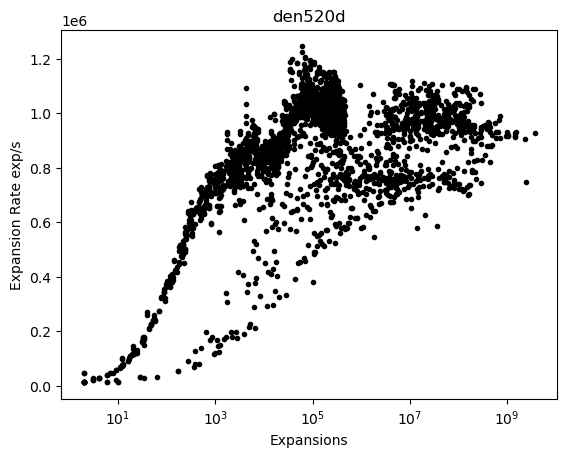

In [7]:
plt.plot(data.sum_expanded, data.sum_expanded/(data.runtime / 1000), ".k")
plt.xscale("log")
plt.xlabel("Expansions")
plt.ylabel("Expansion Rate exp/s")
plt.title("den520d")
plt.show()

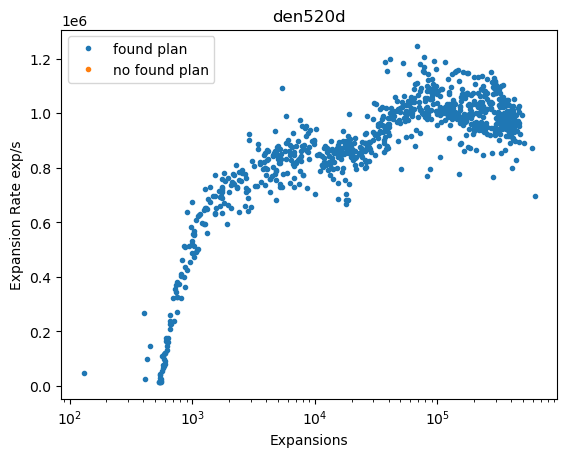

In [8]:
dat = data[(data.arrival_time < 1000) * (data.algorithm == "sipp")]
plt.plot(dat.sum_generated, dat.sum_expanded/(dat.runtime / 1000), ".", label = "found plan")
dat = data[(data.arrival_time >= 1000) * (data.algorithm == "sipp")]
plt.plot(dat.sum_generated, dat.sum_expanded/(dat.runtime / 1000), ".", label = "no found plan")

plt.xscale("log")
plt.xlabel("Expansions")
plt.ylabel("Expansion Rate exp/s")
plt.title("den520d")
#plt.ylim([400000, 1000000])
plt.legend()
plt.savefig("overhead2.png")

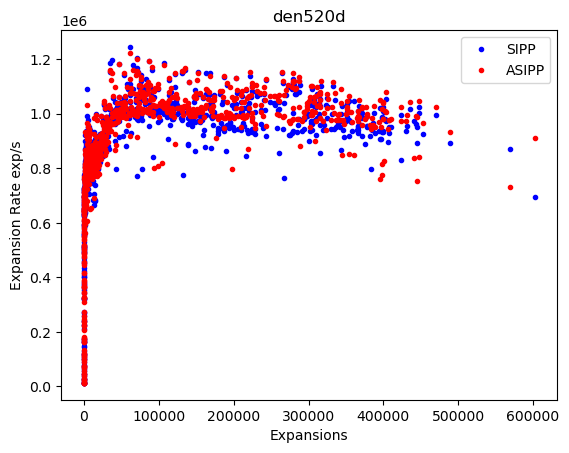

In [10]:
asipp_dat = data[data.algorithm == "asipp"]
sipp_dat = data[data.algorithm == "sipp"]

plt.plot(sipp_dat.sum_expanded, sipp_dat.sum_expanded/(sipp_dat.runtime / 1000), ".b", label = "SIPP")
plt.plot(asipp_dat.sum_expanded, asipp_dat.sum_expanded/(asipp_dat.runtime / 1000), ".r", label = "ASIPP")

#plt.xscale("log")
plt.xlabel("Expansions")
plt.ylabel("Expansion Rate exp/s")
plt.title("den520d")
#plt.ylim([400000, 1000000])
plt.legend()
plt.savefig("overhead.png")

In [11]:
100*(asipp_dat.runtime.sum() - sipp_dat.runtime.sum())/sipp_dat.runtime.sum()

np.float64(-1.9921872935698701)

In [95]:
dat = data[data.algorithm == "asipp"]
dat

,filename,algorithm,seed,start_x,start_y,goal_x,goal_y,sum_generated,sum_decreased,sum_expanded,n_tref,runtime
1,maps/den520/den520d.map,asipp,0,140,226,13,74,17072,625,17073,1,20.685500
2,maps/den520/den520d.map,asipp,2,148,215,211,195,14535,444,14536,1,16.534200
3,maps/den520/den520d.map,asipp,1,100,41,122,35,478,20,219,1,0.426745
4,maps/den520/den520d.map,asipp,2,171,119,161,50,2807,179,1701,1,2.628950
6,maps/den520/den520d.map,asipp,2,94,173,14,189,48922,1672,48923,1,70.801700
...,...,...,...,...,...,...,...,...,...,...,...,...
7814,maps/den520/den520d.map,asipp,1,87,177,225,182,47563,1546,47564,1,64.926800
7815,maps/den520/den520d.map,asipp,1,217,71,143,95,43942,1504,43943,1,63.072300
7817,maps/den520/den520d.map,asipp,2,58,150,243,53,42398,1422,42399,1,57.592200
7819,maps/den520/den520d.map,asipp,0,127,168,152,45,38777,1456,38778,1,54.724700


In [14]:
dat = data[data.algorithm == "repeat"]
dat

,filename,algorithm,seed,start_x,start_y,goal_x,goal_y,sum_generated,sum_decreased,sum_expanded,n_tref,runtime,node,arrival_time,instance_id,replicate
0,maps/den520/den520d.map,repeat,0,213,58,216,68,40066,629,2677,61,13.62853,ai7,0.0,26,0
6,maps/den520/den520d.map,repeat,0,192,77,100,33,34634278,2392211,25292468,2460,32703.93170,ai3,0.0,271,0
9,maps/den520/den520d.map,repeat,0,178,74,109,157,13031947,682134,10590827,442,13509.27810,ai8,0.0,328,0
11,maps/den520/den520d.map,repeat,0,52,77,227,113,4633749,254455,3882946,99,4451.32200,ai15,0.0,510,0
14,maps/den520/den520d.map,repeat,0,30,73,73,199,85675645,2467028,81089334,359,75618.68300,ai3,0.0,685,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2598,maps/den520/den520d.map,repeat,0,70,137,123,50,28906515,859513,26849207,161,25761.87100,ai9,0.0,587,0
2599,maps/den520/den520d.map,repeat,0,158,158,225,119,66881406,2109412,61244924,722,59331.22080,ai12,0.0,357,0
2601,maps/den520/den520d.map,repeat,0,79,92,194,74,197881,17723,135510,18,184.09991,ai3,0.0,309,0
2602,maps/den520/den520d.map,repeat,0,217,71,143,95,16113938,1438093,10368911,2120,15162.64701,ai15,0.0,206,0


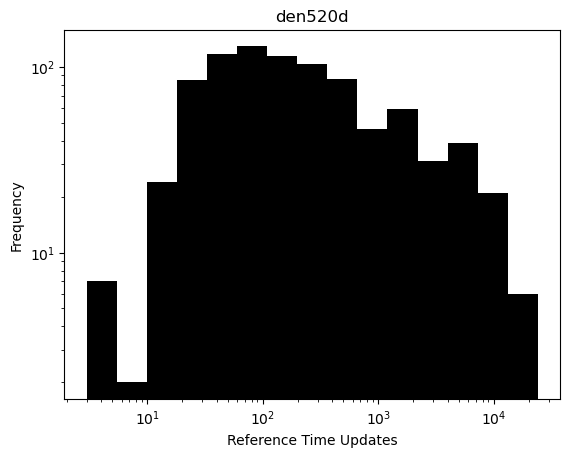

In [15]:
logbins = np.geomspace(dat.n_tref.min(), dat.n_tref.max(), 16) 
plt.hist(dat.n_tref, bins = logbins, facecolor="k")
plt.yscale("log")
plt.xscale("log")
plt.ylabel("Frequency")
plt.xlabel("Reference Time Updates")
plt.title("den520d")
plt.savefig("plan-size.png")

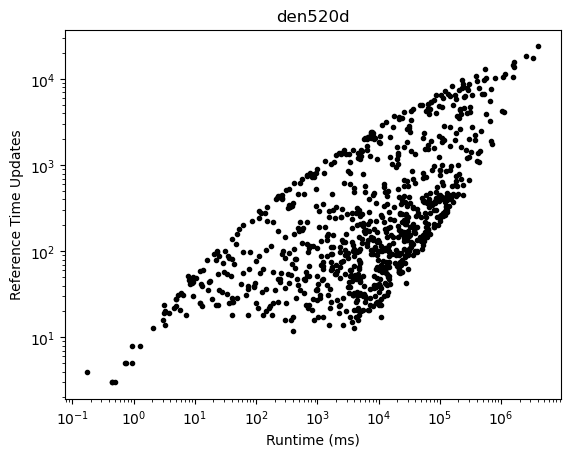

In [16]:
plt.plot(dat.runtime, dat.n_tref, ".k")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Runtime (ms)")
plt.ylabel("Reference Time Updates")
plt.title("den520d")
plt.savefig("rtplan.png")